In [156]:
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os

print("Python:", sys.version.split()[0])
print("scanpy:", sc.__version__)

Python: 3.12.12
scanpy: 1.11.5


/tmp/ipykernel_1737275/56635175.py:9: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy:", sc.__version__)


In [157]:
out_dir  = "/data/projects/oscar/Miranda/results"
A_sub = sc.read_h5ad(f"{out_dir}/sub_adata_microglia_leiden6_noOutside.h5ad")

In [158]:
import scanpy as sc
import numpy as np
import scipy.sparse as sp

SUB_PATH = "/data/projects/oscar/Miranda/results/sub_adata_microglia_leiden6_noOutside.h5ad"
PRE_PATH = "/data/projects/oscar/Miranda/results/adata_consol_newslides_qc_filter_protectmicroglia.h5ad"

sub = sc.read_h5ad(SUB_PATH)
pre = sc.read_h5ad(PRE_PATH)

# normalize+log1p on pre (this overwrites pre.X)
sc.pp.normalize_total(pre, target_sum=1e4)
sc.pp.log1p(pre)

# safety: check obs_names overlap
missing = sub.obs_names.difference(pre.obs_names)
if len(missing) > 0:
    raise RuntimeError(
        f"{len(missing)} subcluster cells not found in preproc by obs_names.\n"
        f"Example missing: {list(missing[:5])}"
    )

#  align pre to sub (cells + genes in same order)
pre_aligned = pre[sub.obs_names, :].copy()

# if gene order differs, reorder genes to match sub
if not np.array_equal(pre_aligned.var_names, sub.var_names):
    # this will also error if some genes are missing
    pre_aligned = pre_aligned[:, sub.var_names].copy()

# attach log1p matrix as a layer on sub
sub.layers["log1p"] = pre_aligned.X.copy()

print("Attached sub.layers['log1p']:", sub.layers["log1p"].shape)


Attached sub.layers['log1p']: (67022, 347)


# Gate 1

In [159]:
# check/gate microglia
# Define canonical microglial markers
A_sub = sub
microglia_markers = ["Trem2","Cx3cr1","P2ry12","Itgam","Aif1", "Spi1", "Tmem119", "Tyrobp", "Hexb"]

# Keep only markers present
markers_present = [g for g in microglia_markers if g in A_sub.var_names]
print("Markers present:", markers_present)

# Extract expression matrix for those genes
X = A_sub[:, markers_present].layers["log1p"]

# If sparse matrix, convert safely
if not isinstance(X, np.ndarray):
    X = X.toarray()

# Define expression threshold
# Since data is log1p-normalized, > 0 means at least 1 raw count
expr_binary = X > 0

# Count number of expressed markers per cell
marker_count = expr_binary.sum(axis=1)

# Add to metadata
A_sub.obs["microglia_marker_count"] = marker_count

# Gate: at least 1 markers expressed
A_sub.obs["microglia_marker_gate"] = np.where(
    marker_count >= 1, ##############################################################################################################################
    "Microglial_marker_pos",
    "Microglial_marker_low"
)

# Make categorical for clean plotting
A_sub.obs["microglia_marker_gate"] = A_sub.obs["microglia_marker_gate"].astype("category")

Markers present: ['Trem2', 'Cx3cr1', 'P2ry12', 'Itgam', 'Aif1', 'Spi1', 'Tmem119', 'Tyrobp', 'Hexb']


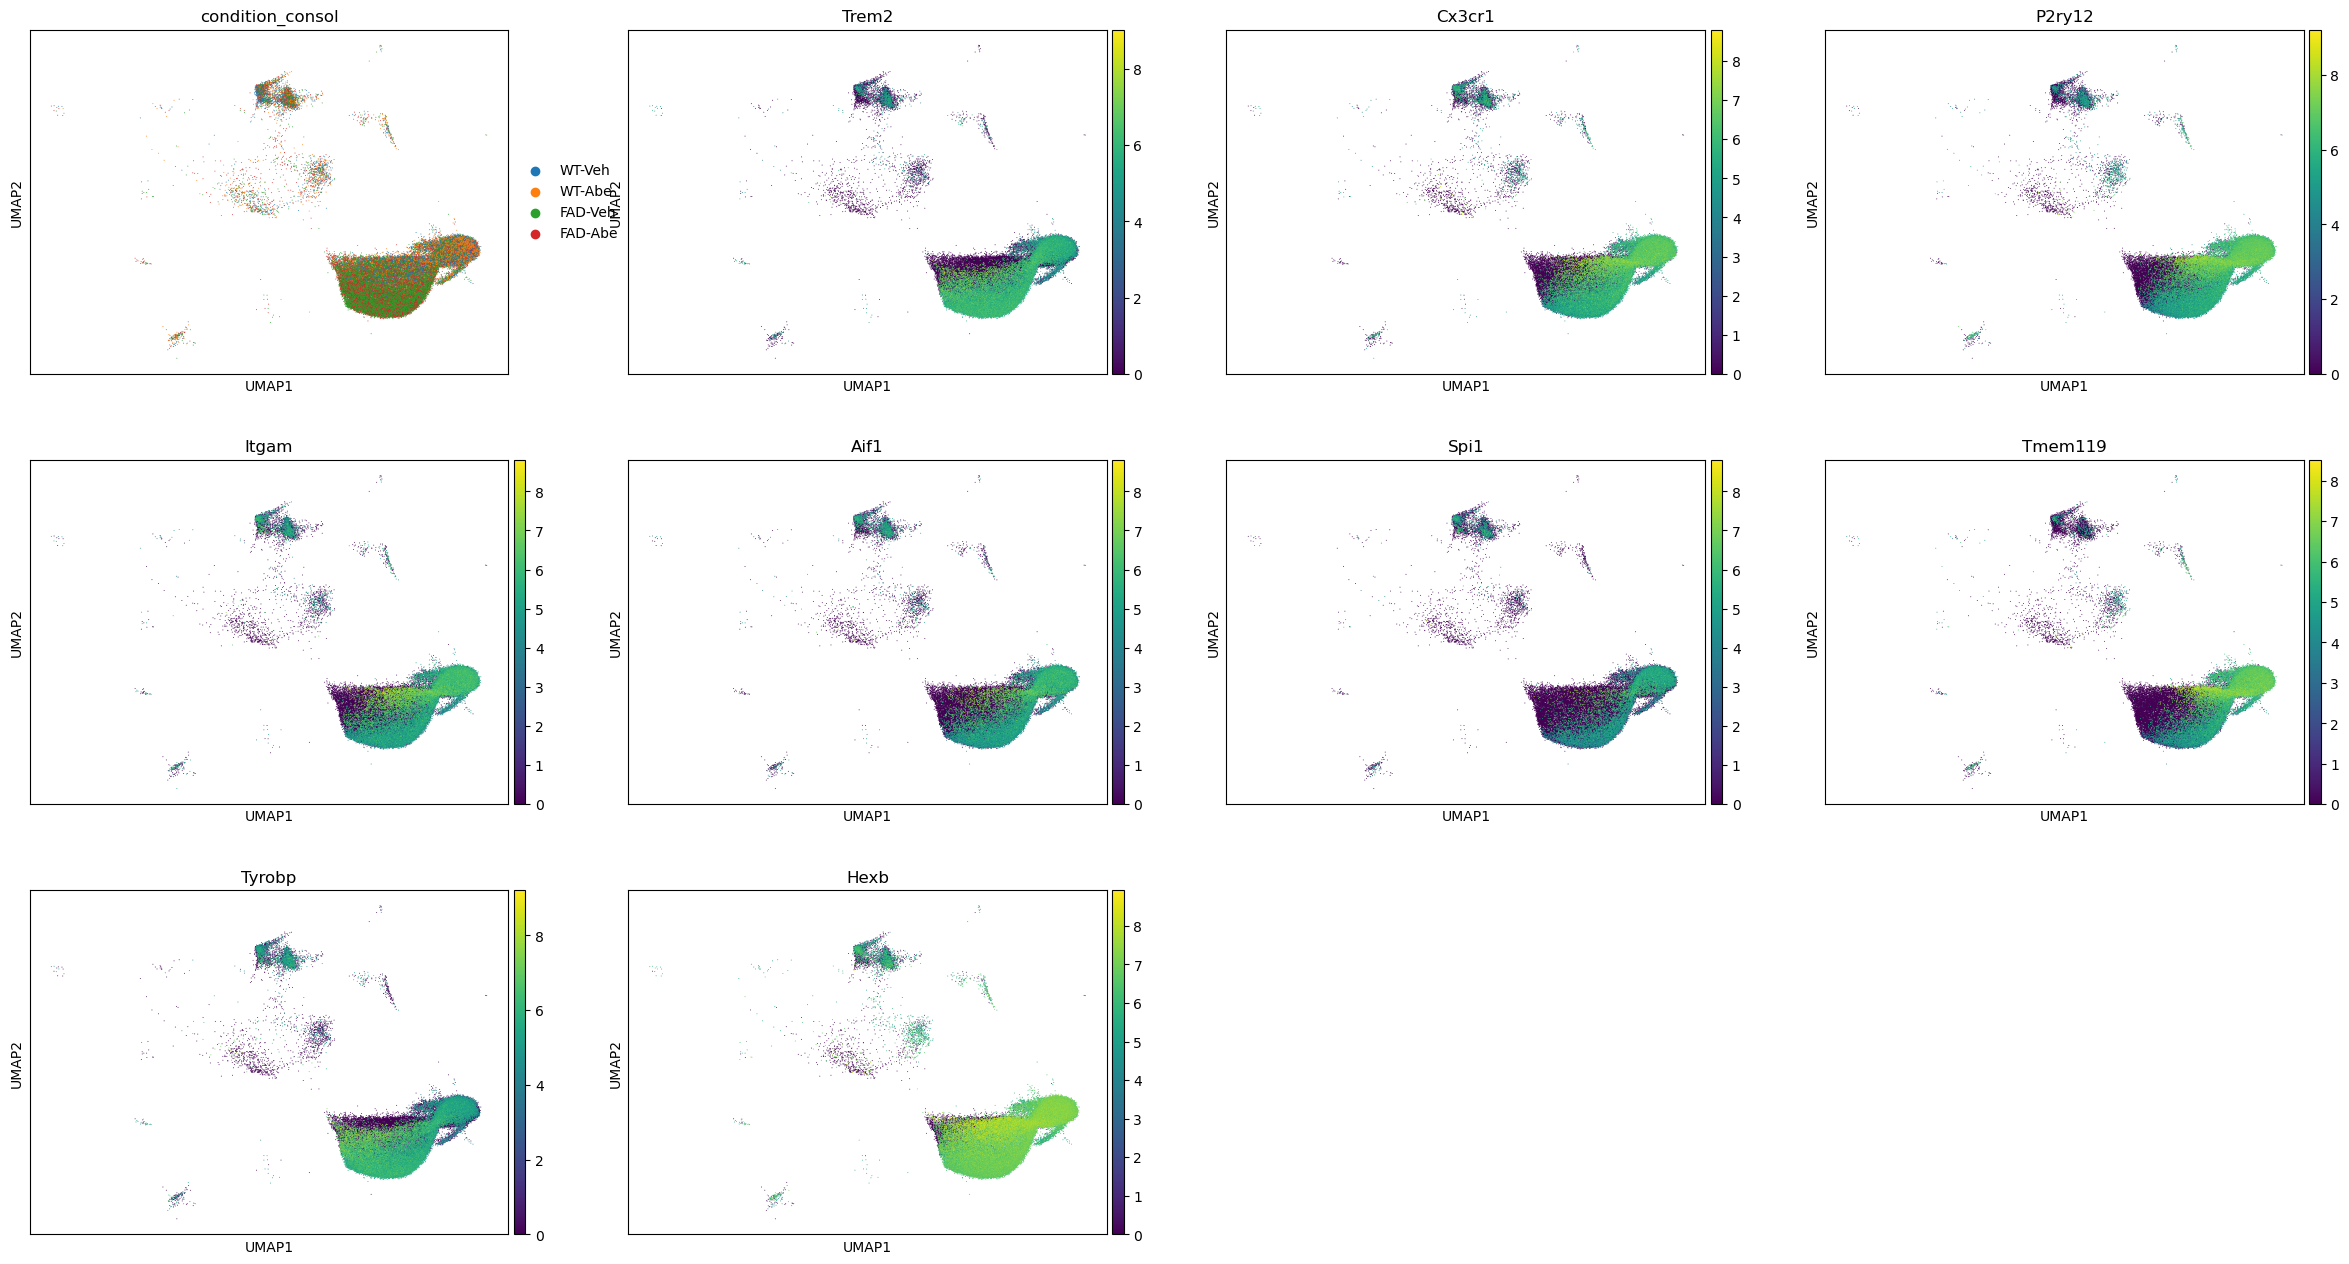

In [160]:
plot_genes_A_sub = [g for g in markers_present if g in A_sub.var_names] # C1qb not in panel
sc.pl.umap(A_sub, color=["condition_consol"] + plot_genes_A_sub, layer="log1p", ncols=4)

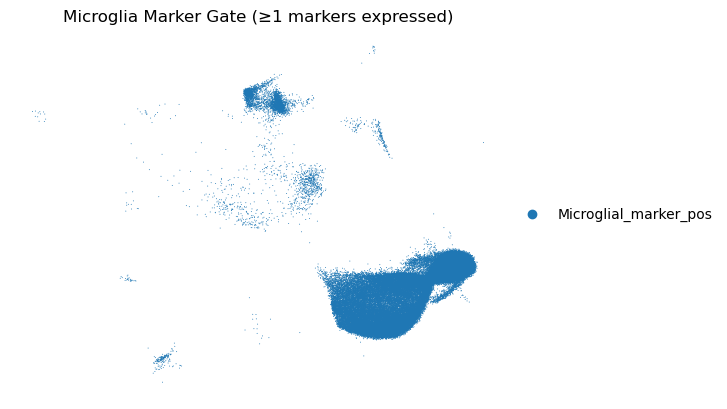

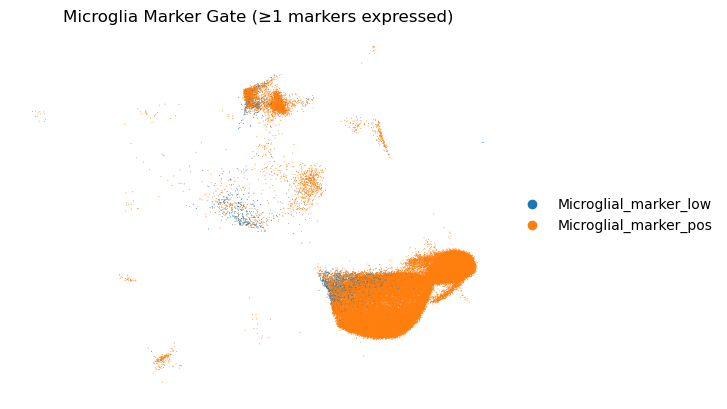

In [161]:
# Subset only marker-positive cells for plotting
A_sub_pos = A_sub[A_sub.obs["microglia_marker_gate"] == "Microglial_marker_pos"].copy()

sc.pl.umap(
    A_sub_pos,
    color="microglia_marker_gate",
    frameon=False,
    title="Microglia Marker Gate (≥1 markers expressed)"
)
sc.pl.umap(
    A_sub,
    color="microglia_marker_gate",
    frameon=False,
    title="Microglia Marker Gate (≥1 markers expressed)"
)

In [162]:
A_sub.obs["microglia_marker_gate"].value_counts()

microglia_marker_gate
Microglial_marker_pos    64716
Microglial_marker_low     2306
Name: count, dtype: int64

# Gate 2

In [163]:
import numpy as np
import scipy.sparse as sp

A_sub = A_sub_pos

microglia_markers = [
    "Trem2","Cx3cr1","P2ry12","Itgam","Aif1",
    "Spi1","Tmem119","Tyrobp","Hexb"
]

markers_present = [g for g in microglia_markers if g in A_sub.var_names]
print("Markers present:", markers_present)

X = A_sub[:, markers_present].layers["log1p"]

if sp.issparse(X):
    combined_score = np.asarray(X.sum(axis=1)).ravel()
else:
    combined_score = X.sum(axis=1)

A_sub.obs["microglia_combined_score"] = combined_score

Markers present: ['Trem2', 'Cx3cr1', 'P2ry12', 'Itgam', 'Aif1', 'Spi1', 'Tmem119', 'Tyrobp', 'Hexb']


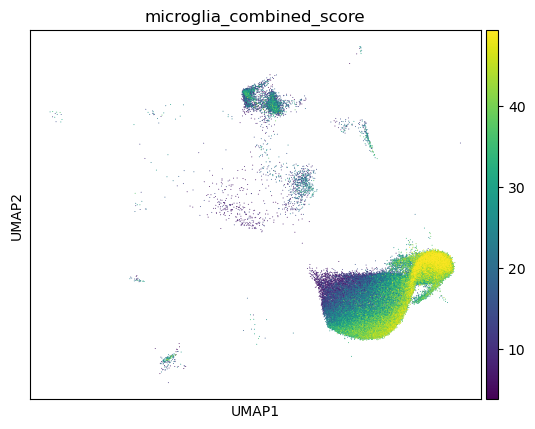

In [164]:
sc.pl.umap(
    A_sub,
    color="microglia_combined_score",
    vmax="p99",
    cmap="viridis"
)

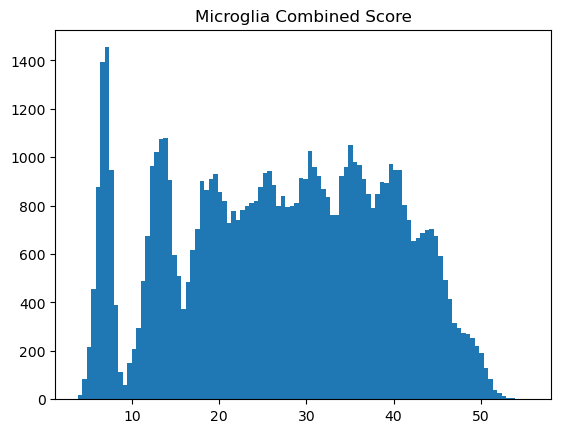

In [165]:
import matplotlib.pyplot as plt
plt.hist(A_sub.obs["microglia_combined_score"], bins=100)
plt.title("Microglia Combined Score")
plt.show()

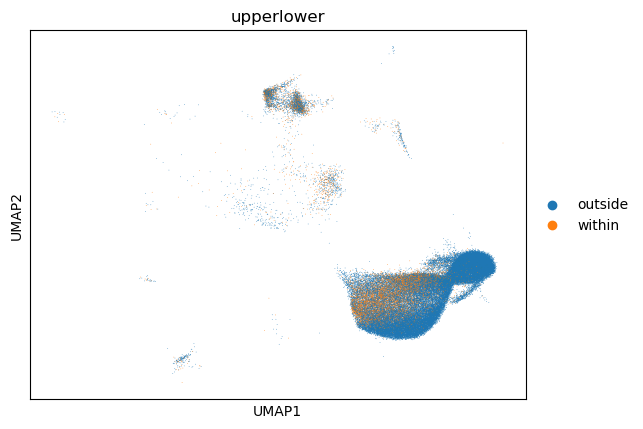

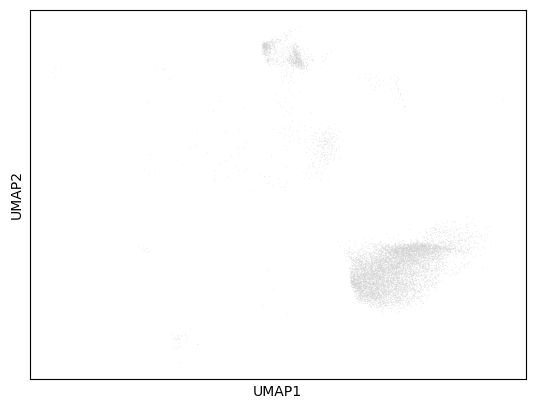

In [166]:
A_sub10_18 = A_sub.copy()
A_sub10_18.obs["upperlower"] = np.where(
    ((A_sub10_18.obs["microglia_combined_score"] >= 10) & (A_sub10_18.obs["microglia_combined_score"] <= 18)),
    "within",
    "outside"
)
sc.pl.umap(A_sub10_18, color = "upperlower", size=1)

A_sub10_18_only = A_sub[
    (A_sub.obs["microglia_combined_score"] >= 10) &
    (A_sub.obs["microglia_combined_score"] <= 18)
].copy()

sc.pl.umap(A_sub10_18_only, size=1)

In [167]:
#threshold = np.percentile(A_sub.obs["microglia_combined_score"], 30)
threshold = 10
A_sub.obs["microglia_combined_gate"] = np.where(
    A_sub.obs["microglia_combined_score"] > threshold,
    "Microglia_high",
    "Low"
)
A_sub.obs["microglia_combined_gate"] = A_sub.obs["microglia_combined_gate"].astype("category")

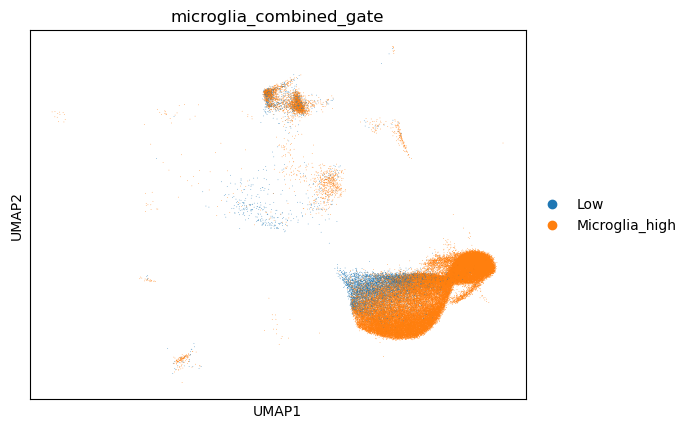

In [168]:
sc.pl.umap(A_sub, color="microglia_combined_gate", size=1)

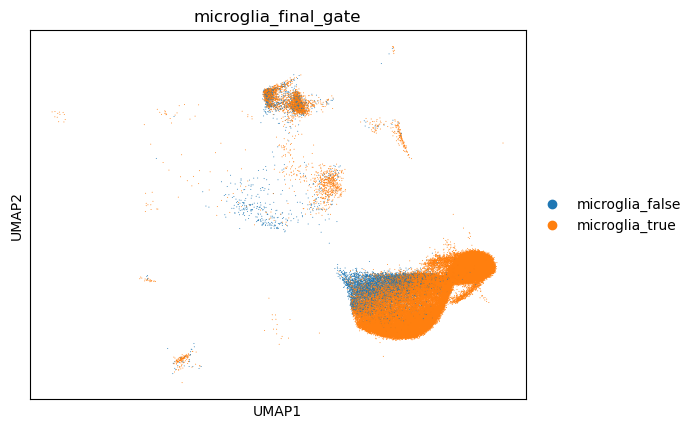

In [171]:
final_gate = (
    (A_sub.obs["microglia_marker_count"] >= 1) &
    (A_sub.obs["microglia_combined_score"] > threshold)
)

A_sub.obs["microglia_final_gate"] = np.where(final_gate, "microglia_true", "microglia_false")
A_sub.obs["microglia_final_gate"] = A_sub.obs["microglia_final_gate"].astype("category")
sc.pl.umap(A_sub, color="microglia_final_gate")

In [182]:
A_sub = A_sub[A_sub.obs["microglia_final_gate"] == 'microglia_true']
outpath = "/data/projects/oscar/Miranda/results/regatex2"
out_dir = f"{outpath}/sub_adata_microglia_leiden6_noOutside_gatex2.h5ad"
os.makedirs(outpath, exist_ok=True)

A_sub.write_h5ad(out_dir, compression = 'gzip')

In [184]:
print(A_sub.obs["microglia_final_gate"].value_counts())
print((A_sub.obs["microglia_combined_score"] > 10).sum())

microglia_final_gate
microglia_true    58553
Name: count, dtype: int64
58553


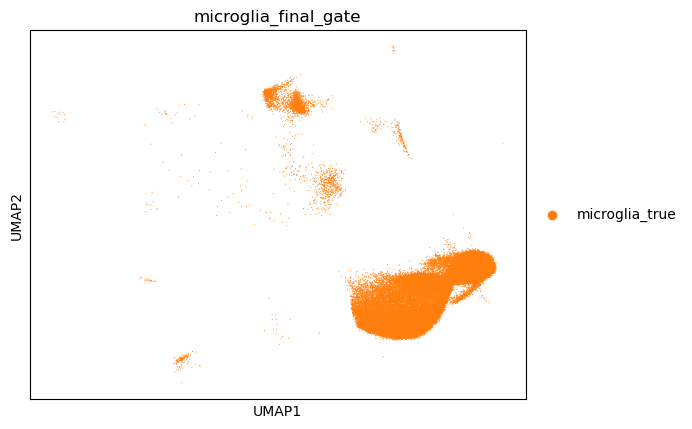

In [185]:
sc.pl.umap(A_sub, color="microglia_final_gate")

In [187]:
print((A_sub.obs["microglia_marker_count"] >= 1).sum())

58553
